# 1 — Tabular admin hierarchy

Shows `scale_variance` applied to a non-spatial, ragged hierarchy — counties within states within regions. No raster, no CRS, no geometry. This is the same family of problem as the fixture `fixture_irregular_admin` in the parity suite. The expected totals here are hand-verifiable.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scalevar import scale_variance

## Build a ragged hierarchy

Six states, two regions, 24 counties with deliberately irregular fan-out (some states have three counties, others five). Values are constructed so that each region-level mean differs cleanly from the others — that's the signal at the coarsest scale.

In [2]:
rows = [
    # (county_id, state_id, region_id, value)
    (1, 1, 1, 10), (2, 1, 1, 20), (3, 1, 1, 30),
    (4, 2, 1, 8), (5, 2, 1, 14), (6, 2, 1, 20), (7, 2, 1, 26), (8, 2, 1, 32),
    (9, 3, 2, 40), (10, 3, 2, 50), (11, 3, 2, 60),
    (12, 4, 2, 38), (13, 4, 2, 44), (14, 4, 2, 50), (15, 4, 2, 56), (16, 4, 2, 62),
    (17, 5, 2, 70), (18, 5, 2, 80), (19, 5, 2, 90),
    (20, 6, 2, 68), (21, 6, 2, 74), (22, 6, 2, 80), (23, 6, 2, 86), (24, 6, 2, 92),
]
df = pd.DataFrame(rows, columns=['county_id', 'state_id', 'region_id', 'value'])
df.head()

,county_id,state_id,region_id,value
0,1,1,1,10
1,2,1,1,20
2,3,1,1,30
3,4,2,1,8
4,5,2,1,14


## Decompose

In [3]:
result = scale_variance(
    df,
    value='value',
    id_cols=['county_id', 'state_id', 'region_id'],
    agg_fun='mean',
)

print(f'TSS        = {result.total_ss:.1f}')
print(f'grand_mean = {result.grand_mean}')
print(f'total_df   = {result.total_df}')
result.components.round(4)

TSS        = 16080.0
grand_mean = 50.0
total_df   = 23


,level,scale,sum_squares,df,mean_square,ss_share,ms_share,ss_cumulative
0,1,NaN,1680.0,18,93.3333,0.1045,0.0079,0.1045
1,2,NaN,3600.0,4,900.0000,0.2239,0.0763,0.3284
2,3,NaN,10800.0,1,10800.0000,0.6716,0.9158,1.0000


About two-thirds of the total variance lives at the **region** level (the coarsest), about 22% at the **state** level, and only about 10% within states — which matches the design (values were chosen to put most of the signal at the top). The identity `Σ SS_n = TSS` holds exactly.


In [4]:
assert abs(result.components['sum_squares'].sum() - result.total_ss) < 1e-9
assert result.components['df'].sum() == result.total_df
assert abs(result.components['ss_share'].sum() - 1.0) < 1e-10
'identities hold'

'identities hold'

## Plot the variance share by scale

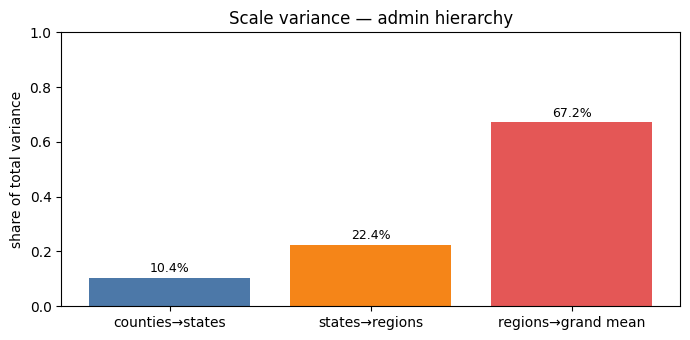

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ['counties→states', 'states→regions', 'regions→grand mean']
bars = ax.bar(labels, result.components['ss_share'], color=['#4c78a8', '#f58518', '#e45756'])
ax.set_ylabel('share of total variance')
ax.set_ylim(0, 1)
ax.set_title('Scale variance — admin hierarchy')
for bar, share in zip(bars, result.components['ss_share'], strict=True):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{share*100:.1f}%', ha='center', fontsize=9)
fig.tight_layout()
plt.show()

## Inspecting elements (where variance accumulates per level)

`result.elements[n]` gives one row per distinct level-`n` cell, each row showing that cell's contribution `sv = (parent − child)²`.

In [6]:
# Which states contribute the most to within-state variance?
states = result.elements[2].sort_values('sv', ascending=False)
states

,id,mean_child,mean_parent,sv,sv_per_df
2,3,50.0,65.0,225.0,56.25
3,4,50.0,65.0,225.0,56.25
4,5,80.0,65.0,225.0,56.25
5,6,80.0,65.0,225.0,56.25
0,1,20.0,20.0,0.0,0.00
1,2,20.0,20.0,0.0,0.00


All six states contribute equally at the state→region step because deviations `|region_mean − state_mean|` are symmetric in this toy example. The full fixture (`tests/fixtures/fixture_irregular_admin`) exercises the same code path with hand-derived expected values at every level.